In [1]:
# ==============================================================================
# CELL 1: DOWNLOAD DATASET
# ==============================================================================
import kagglehub

# Unduh dataset e-commerce dari Kaggle
path = kagglehub.dataset_download("carrie1/ecommerce-data")
print("Path to dataset files:", path)

100%|██████████| 7.20M/7.20M [00:00<00:00, 34.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/carrie1/ecommerce-data/versions/1


In [2]:
# ==============================================================================
# CELL 2: LOAD DATA & CLEANING RETUR
# ==============================================================================
import pandas as pd
import os

# Deteksi file CSV di dalam folder unduhan
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
file_path = os.path.join(path, csv_file)

# Load data dengan encoding yang sesuai
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# FILTERING: Buang transaksi minus/retur untuk menjaga validitas prediksi stok riil gudang
df = df[df['Quantity'] > 0].reset_index(drop=True)

print(f"--- Data Berhasil Dimuat. Total Baris: {df.shape[0]} ---")
print(df.head())

--- Data Berhasil Dimuat. Total Baris: 531285 ---
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [3]:
# ==============================================================================
# CELL 3: SUNTIK FITUR EKSTERNAL (WILAYAH & CUACA)
# ==============================================================================
import numpy as np

def dapatkan_benua(country):
    if country in ['United Kingdom', 'Germany', 'France', 'EIRE', 'Spain', 'Netherlands',
                   'Belgium', 'Switzerland', 'Portugal', 'Norway', 'Italy', 'Channel Islands',
                   'Finland', 'Austria', 'Denmark', 'Poland', 'Iceland', 'Greece', 'Malta',
                   'European Community', 'Lithuania', 'Czech Republic']:
        return 'Eropa_Utara_Barat'
    elif country in ['Japan', 'Hong Kong', 'Singapore', 'Israel', 'USA', 'Canada',
                     'United Arab Emirates', 'Lebanon', 'Bahrain', 'Saudi Arabia', 'Cyprus']:
        return 'Asia_Amerika_Utara'
    elif country in ['Australia', 'RSA', 'Brazil']:
        return 'Belahan_Bumi_Selatan'
    else:
        return 'Eropa_Utara_Barat'

# Konversi waktu dan ekstraksi bulan serta wilayah
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.month
df['Region_Cluster'] = df['Country'].apply(dapatkan_benua)

def suntik_cuaca_otomatis(row):
    bulan = row['Month']
    wilayah = row['Region_Cluster']

    if wilayah == 'Eropa_Utara_Barat':
        if bulan in [12, 1, 2]:   return pd.Series(['Salju/Hujan_Dingin', 'Sangat_Dingin'])
        elif bulan in [3, 4, 5]:  return pd.Series(['Cerah_Berawan', 'Sejuk'])
        elif bulan in [6, 7, 8]:  return pd.Series(['Cerah', 'Hangat'])
        else:                     return pd.Series(['Hujan/Mendung', 'Dingin'])

    elif wilayah == 'Asia_Amerika_Utara':
        if bulan in [12, 1, 2]:   return pd.Series(['Hujan/Berawan', 'Dingin'])
        elif bulan in [3, 4, 5]:  return pd.Series(['Cerah', 'Hangat'])
        elif bulan in [6, 7, 8]:  return pd.Series(['Sangat_Panas/Gersang', 'Sangat_Panas'])
        else:                     return pd.Series(['Cerah', 'Hangat'])

    elif wilayah == 'Belahan_Bumi_Selatan':
        if bulan in [12, 1, 2]:   return pd.Series(['Cerah/Terik', 'Panas'])
        elif bulan in [3, 4, 5]:  return pd.Series(['Hujan/Angin', 'Sejuk'])
        elif bulan in [6, 7, 8]:  return pd.Series(['Mendung/Dingin', 'Dingin'])
        else:                     return pd.Series(['Cerah_Berawan', 'Hangat'])

    return pd.Series(['Cerah', 'Normal'])

# Terapkan fungsi cuaca
print("Sedang menyuntikkan fitur cuaca...")
df[['Weather_Condition', 'Temperature_Category']] = df.apply(suntik_cuaca_otomatis, axis=1)

Sedang menyuntikkan fitur cuaca...


In [4]:
# ==============================================================================
# CELL 4: SUNTIK FITUR HARI LIBUR NASIONAL
# ==============================================================================
import holidays

df['Date'] = df['InvoiceDate'].dt.date
tahun_dataset = df['InvoiceDate'].dt.year.unique()

country_map = {
    'United Kingdom': 'UK', 'Germany': 'DE', 'France': 'FR', 'Spain': 'ES',
    'Netherlands': 'NL', 'Belgium': 'BE', 'Switzerland': 'CH', 'Portugal': 'PT',
    'Australia': 'AU', 'Norway': 'NO', 'Italy': 'IT', 'Finland': 'FI',
    'Austria': 'AT', 'Denmark': 'DK', 'Poland': 'PL', 'USA': 'US',
    'Japan': 'JP', 'Singapore': 'SG', 'Brazil': 'BR', 'Canada': 'CA'
}

def dapatkan_kalender_libur(df_input, country_map):
    libur_per_negara = {}
    for country_nama, country_kode in country_map.items():
        libur_resmi = holidays.country_holidays(country_kode, years=tahun_dataset)
        set_libur = set(libur_resmi.keys())
        for thn in tahun_dataset:
            if thn == 2010:
                set_libur.update([pd.to_datetime('2010-11-26').date(), pd.to_datetime('2010-11-29').date()])
            elif thn == 2011:
                set_libur.update([pd.to_datetime('2011-11-25').date(), pd.to_datetime('2011-11-28').date()])
        libur_per_negara[country_nama] = set_libur
    return libur_per_negara

kamus_libur_global = dapatkan_kalender_libur(df, country_map)

def hitung_jarak_ke_libur(row):
    tgl_sekarang = row['Date']
    negara = row['Country']
    daftar_libur = kamus_libur_global.get(negara, kamus_libur_global['United Kingdom'])
    libur_mendatang = [lbr for lbr in daftar_libur if lbr >= tgl_sekarang]

    if libur_mendatang:
        libur_terdekat = min(libur_mendatang)
        jarak = (libur_terdekat - tgl_sekarang).days
        is_holiday = 1 if jarak == 0 else 0
        return pd.Series([is_holiday, jarak])
    else:
        return pd.Series([0, 999])

print("Sedang memproses jarak hari libur nasional...")
df[['Is_Holiday', 'Days_To_Holiday']] = df.apply(hitung_jarak_ke_libur, axis=1)

Sedang memproses jarak hari libur nasional...


In [5]:
# ==============================================================================
# CELL 5: AGREGASI, FITUR HARGA, & TARGET JENDELA 7 HARI (OPTIMIZED LAGS)
# ==============================================================================
print("=== MEMPROSES AGREGASI & PEMBENTUKAN TARGET JENDELA 7 HARI ===")

df_daily_products = df.groupby(['Date', 'StockCode']).agg({
    'Quantity': 'sum',
    'UnitPrice': 'mean',
    'Is_Holiday': 'max',
    'Days_To_Holiday': 'min',
    'Weather_Condition': 'first',
    'Temperature_Category': 'first',
    'Region_Cluster': 'first'
}).reset_index()

df_daily_products = df_daily_products.sort_values(['StockCode', 'Date']).reset_index(drop=True)
df_daily_products['Date'] = pd.to_datetime(df_daily_products['Date'])

# Ekstraksi Fitur Kalender
df_daily_products['DayOfWeek'] = df_daily_products['Date'].dt.dayofweek
df_daily_products['Month'] = df_daily_products['Date'].dt.month
df_daily_products['Is_Weekend'] = df_daily_products['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
df_daily_products['Is_MonthEnd'] = df_daily_products['Date'].dt.is_month_end.astype(int)

# OPTIMASI: Hanya buat Lag_1 (tren harian) dan Lag_7 (pola mingguan)
df_daily_products['Quantity_Lag_1'] = df_daily_products.groupby('StockCode')['Quantity'].shift(1)
df_daily_products['Quantity_Lag_7'] = df_daily_products.groupby('StockCode')['Quantity'].shift(7)

df_daily_products['Quantity_Rolling_Mean_7'] = (
    df_daily_products.groupby('StockCode')['Quantity_Lag_1']
    .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
)

# Pembuatan Target Horizon 7 Hari
df_daily_products['Quantity_Next_7_Days'] = (
    df_daily_products.groupby('StockCode')['Quantity']
    .transform(lambda x: x.shift(-7).rolling(window=7, min_periods=7).sum())
)

df_daily_products_clean = df_daily_products.dropna().reset_index(drop=True)
print(f"✅ Selesai! Dimensi Data siap pakai: {df_daily_products_clean.shape}")

=== MEMPROSES AGREGASI & PEMBENTUKAN TARGET JENDELA 7 HARI ===
✅ Selesai! Dimensi Data siap pakai: (229825, 17)


In [10]:
# ==============================================================================
# CELL 6: TIME-SERIES SPLIT & TARGET ENCODING (LEAKAGE-FREE)
# ==============================================================================
import pandas as pd
import numpy as np

df_model = df_daily_products_clean.copy()
df_model['Date'] = pd.to_datetime(df_model['Date'])

# 1. Tentukan Cutoff Time-Series Split Terlebih Dahulu
cutoff_date = pd.to_datetime('2011-11-01')
is_train = df_model['Date'] < cutoff_date
is_test = df_model['Date'] >= cutoff_date

# 2. Hitung Target Encoding HANYA dari Data Train (Bebas Leakage)
train_stock_mean = df_model[is_train].groupby('StockCode')['Quantity_Next_7_Days'].mean().to_dict()
global_train_mean = df_model[is_train]['Quantity_Next_7_Days'].mean()

# Petakan ke dataset. Jika ada produk baru di data test, gunakan nilai global mean
df_model['StockCode_Encoded'] = df_model['StockCode'].map(train_stock_mean).fillna(global_train_mean)

# 3. Log-Transformation Target
y = np.log1p(df_model['Quantity_Next_7_Days'])

# 4. Drop kolom identifier mentah
X = df_model.drop(columns=['Quantity', 'Quantity_Next_7_Days', 'Date', 'StockCode'])

# 5. Konversi kolom teks kategorikal ke tipe 'category' pandas
kolom_kategorikal = ['Weather_Condition', 'Temperature_Category', 'Region_Cluster']
for col in kolom_kategorikal:
    X[col] = X[col].astype('category')

# 6. Pemisahan Matriks X_train, y_train, X_test, y_test
X_train, y_train = X[is_train], y[is_train]
X_test, y_test = X[is_test], y[is_test]

# 7. Output Verifikasi
print("==========================================================")
print(" HASIL PEMBAGIAN DATA & TARGET ENCODING (BEBAS LEAKAGE) ")
print("==========================================================")
print(f"📐 Dimensi Matriks X (Fitur Ringkas) : {X.shape[0]:,} baris, {X.shape[1]} kolom")
print(f"📦 Total Baris Data Train (X_train) : {X_train.shape[0]:,} baris")
print(f"📦 Total Baris Data Test  (X_test)  : {X_test.shape[0]:,} baris")
print(f"🔹 Rentang Waktu TRAIN : {df_model.loc[is_train, 'Date'].min().strftime('%Y-%m-%d')} s/d {df_model.loc[is_train, 'Date'].max().strftime('%Y-%m-%d')}")
print(f"🔸 Rentang Waktu TEST  : {df_model.loc[is_test, 'Date'].min().strftime('%Y-%m-%d')} s/d {df_model.loc[is_test, 'Date'].max().strftime('%Y-%m-%d')}")
print("==========================================================")

 HASIL PEMBAGIAN DATA & TARGET ENCODING (BEBAS LEAKAGE) 
📐 Dimensi Matriks X (Fitur Ringkas) : 229,825 baris, 14 kolom
📦 Total Baris Data Train (X_train) : 201,877 baris
📦 Total Baris Data Test  (X_test)  : 27,948 baris
🔹 Rentang Waktu TRAIN : 2010-12-09 s/d 2011-10-31
🔸 Rentang Waktu TEST  : 2011-11-01 s/d 2011-12-01


In [11]:
# ==============================================================================
# CELL 7: PROSES EKSPERIMEN MODEL BASELINE (NATIVE CATEGORICAL SUPPORT)
# ==============================================================================
!pip install catboost -q

import time
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Fungsi Evaluasi: Mengembalikan skala log ke skala unit fisik 7 hari yang riil
def evaluasi_model(nama_model, y_asli_log, y_tebakan_log, durasi_latih):
    y_asli_real = np.expm1(y_asli_log)
    y_tebakan_real = np.expm1(y_tebakan_log)

    mae = mean_absolute_error(y_asli_real, y_tebakan_real)
    mse = mean_squared_error(y_asli_real, y_tebakan_real)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_asli_real, y_tebakan_real)

    return {
        'Model Algoritma': nama_model,
        'MAE': round(mae, 2),
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'R² Score (%)': round(r2 * 100, 2),
        'Waktu (Detik)': round(durasi_latih, 2)
    }

hasil_eksperimen = []

# Daftar kolom kategorikal native
kolom_kategorikal = ['Weather_Condition', 'Temperature_Category', 'Region_Cluster']

# ------------------------------------------------------------------------------
# 1. XGBoost Baseline (Memerlukan enable_categorical=True untuk kolom category)
# ------------------------------------------------------------------------------
print("Running XGBoost Baseline (7 Days Target)...")
mulai = time.time()
xgbr = xgb.XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,
    tree_method='hist'
).fit(X_train, y_train)
durasi = time.time() - mulai
hasil_eksperimen.append(evaluasi_model('XGBoost Native', y_test, xgbr.predict(X_test), durasi))

# ------------------------------------------------------------------------------
# 2. LightGBM Baseline (Secara otomatis mendeteksi kolom ber-tipe 'category')
# ------------------------------------------------------------------------------
print("Running LightGBM Baseline (7 Days Target)...")
mulai = time.time()
lgbm = lgb.LGBMRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
).fit(X_train, y_train, categorical_feature=kolom_kategorikal)
durasi = time.time() - mulai
hasil_eksperimen.append(evaluasi_model('LightGBM Native', y_test, lgbm.predict(X_test), durasi))

# ------------------------------------------------------------------------------
# 3. CatBoost Baseline (Menerima string / category via parameter cat_features)
# ------------------------------------------------------------------------------
print("Running CatBoost Baseline (7 Days Target)...")

# Konversi fitur kategorikal ke string khusus untuk CatBoost
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()
for col in kolom_kategorikal:
    X_train_cat[col] = X_train_cat[col].astype(str)
    X_test_cat[col] = X_test_cat[col].astype(str)

mulai = time.time()
catb = CatBoostRegressor(
    iterations=100,
    random_state=42,
    cat_features=kolom_kategorikal,
    verbose=0
).fit(X_train_cat, y_train)
durasi = time.time() - mulai
hasil_eksperimen.append(evaluasi_model('CatBoost Native', y_test, catb.predict(X_test_cat), durasi))

# ------------------------------------------------------------------------------
# RINGKASAN AKHIR BASELINE
# ------------------------------------------------------------------------------
df_summary = pd.DataFrame(hasil_eksperimen)
print("\n" + "="*75)
print("TABEL PERBANDINGAN METRIK EVALUASI BASELINE (NATIVE CATEGORICAL)")
print("="*75)
print(df_summary.to_string(index=False))

Running XGBoost Baseline (7 Days Target)...
Running LightGBM Baseline (7 Days Target)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010259 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1490
[LightGBM] [Info] Number of data points in the train set: 201877, number of used features: 14
[LightGBM] [Info] Start training from score 4.388873
Running CatBoost Baseline (7 Days Target)...

TABEL PERBANDINGAN METRIK EVALUASI BASELINE (NATIVE CATEGORICAL)
Model Algoritma   MAE      MSE   RMSE  R² Score (%)  Waktu (Detik)
 XGBoost Native 87.90 45920.15 214.29         41.38           0.92
LightGBM Native 87.78 45319.56 212.88         42.14           0.88
CatBoost Native 87.77 43522.90 208.62         44.44           5.16


=== PENGUKURAN KONTRIBUSI FITUR (FEATURE IMPORTANCE) ===
                Feature  Importance (%)
      StockCode_Encoded       71.146917
Quantity_Rolling_Mean_7       10.486819
              UnitPrice        5.411920
                  Month        4.818841
        Days_To_Holiday        4.752424
         Quantity_Lag_1        2.074344
         Quantity_Lag_7        0.840971
              DayOfWeek        0.237324
   Temperature_Category        0.116060
         Region_Cluster        0.049711
      Weather_Condition        0.027762
             Is_Holiday        0.025650
             Is_Weekend        0.011257
            Is_MonthEnd        0.000000


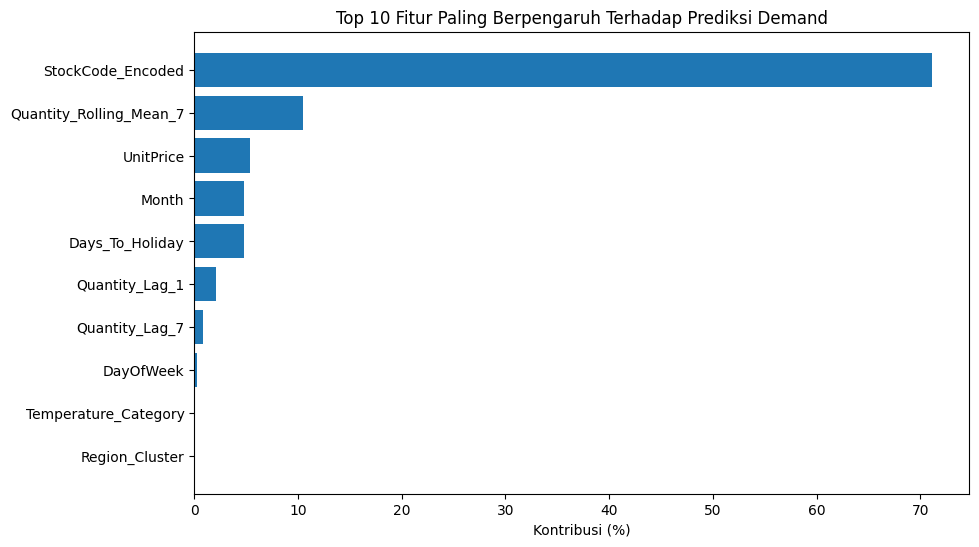

In [12]:
# ==============================================================================
# CELL 8 : ANALISIS FEATURE IMPORTANCE CATBOOST
# ==============================================================================
import matplotlib.pyplot as plt

feature_importance = catb.get_feature_importance()
feature_names = X_train.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance (%)': feature_importance
}).sort_values(by='Importance (%)', ascending=False).reset_index(drop=True)

print("=== PENGUKURAN KONTRIBUSI FITUR (FEATURE IMPORTANCE) ===")
print(df_importance.to_string(index=False))

# Visualisasi
plt.figure(figsize=(10, 6))
plt.barh(df_importance['Feature'][:10][::-1], df_importance['Importance (%)'][:10][::-1])
plt.xlabel("Kontribusi (%)")
plt.title("Top 10 Fitur Paling Berpengaruh Terhadap Prediksi Demand")
plt.show()

In [18]:
# ==============================================================================
# CELL 9: TUNING INCREMENTAL CATBOOST NATIVE
# ==============================================================================
import time
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=== MEMULAI TUNING INCREMENTAL CATBOOST NATIVE (BEBAS LEAKAGE) ===")

# 1. Konversi fitur kategorikal ke tipe string khusus untuk CatBoost
kolom_kategorikal = ['Weather_Condition', 'Temperature_Category', 'Region_Cluster']
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

for col in kolom_kategorikal:
    X_train_cat[col] = X_train_cat[col].astype(str)
    X_test_cat[col] = X_test_cat[col].astype(str)

# 2. Ambil metrik CatBoost Baseline (100 Pohon) dari hasil Cell 8 sebelumnya
catb_baseline_metrics = df_summary[df_summary['Model Algoritma'] == 'CatBoost Native'].iloc[0]

baris_summary_cat = [
    {
        'Jumlah Pohon': 'Baseline (100)',
        'MAE': catb_baseline_metrics['MAE'],
        'RMSE': catb_baseline_metrics['RMSE'],
        'R² Score (%)': f"{catb_baseline_metrics['R² Score (%)']}%",
        'Waktu Latih': f"{catb_baseline_metrics['Waktu (Detik)']}s"
    }
]

# 3. Looping tuning
list_iterations = [300, 500, 800]
model_disimpan = {}

for iters in list_iterations:
    print(f"Sedang melatih CatBoost Native dengan iterations = {iters}...")

    mulai_tune = time.time()
    model_cat = CatBoostRegressor(
        iterations=iters,
        learning_rate=0.05,
        depth=8,
        l2_leaf_reg=3,
        cat_features=kolom_kategorikal,
        random_state=42,
        verbose=0
    ).fit(X_train_cat, y_train)

    durasi = round(time.time() - mulai_tune, 2)

    # Prediksi & konversi kembali skala log ke skala riil unit barang
    y_pred_log = model_cat.predict(X_test_cat)
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)

    # Hitung metrik evaluasi
    mae = round(mean_absolute_error(y_test_real, y_pred_real), 2)
    rmse = round(np.sqrt(mean_squared_error(y_test_real, y_pred_real)), 2)
    r2 = round(r2_score(y_test_real, y_pred_real) * 100, 2)

    # Simpan objek model untuk kebutuhan ekspor rekomendasi stok nanti
    model_disimpan[iters] = model_cat

    baris_summary_cat.append({
        'Jumlah Pohon': f"Tuned ({iters})",
        'MAE': mae,
        'RMSE': rmse,
        'R² Score (%)': f"{r2}%",
        'Waktu Latih': f"{durasi}s"
    })

# 4. Tampilkan Tabel Ringkasan Tuning
tabel_tuning_cat = pd.DataFrame(baris_summary_cat)
print("\n" + "="*75)
print("TABEL PERBANDINGAN TUNING PARAMETER CATBOOST NATIVE")
print("="*75)
print(tabel_tuning_cat.to_string(index=False))
print("="*75)

# 5. Otomatis Tetapkan Model Terbaik Berdasarkan R² Score
best_row = max(baris_summary_cat[1:], key=lambda x: float(x['R² Score (%)'].replace('%','')))
print(f"\n🏆 MODEL TERBAIK HASIL TUNING: CatBoost {best_row['Jumlah Pohon']}")
print(f"   -> R² Score : {best_row['R² Score (%)']}")
print(f"   -> MAE      : {best_row['MAE']} Unit")
print(f"   -> RMSE     : {best_row['RMSE']}")

=== MEMULAI TUNING INCREMENTAL CATBOOST NATIVE (BEBAS LEAKAGE) ===
Sedang melatih CatBoost Native dengan iterations = 300...
Sedang melatih CatBoost Native dengan iterations = 500...
Sedang melatih CatBoost Native dengan iterations = 800...

TABEL PERBANDINGAN TUNING PARAMETER CATBOOST NATIVE
  Jumlah Pohon   MAE   RMSE R² Score (%) Waktu Latih
Baseline (100) 87.77 208.62       44.44%       5.16s
   Tuned (300) 87.19 210.35       43.51%      43.73s
   Tuned (500) 86.69 207.69       44.94%      69.19s
   Tuned (800) 86.41 206.56       45.53%     108.81s

🏆 MODEL TERBAIK HASIL TUNING: CatBoost Tuned (800)
   -> R² Score : 45.53%
   -> MAE      : 86.41 Unit
   -> RMSE     : 206.56


In [19]:
# ==============================================================================
# CELL 10: INTEGRASI REKOMENDASI STOK ABC PARETO (MODEL CATBOOST 800)
# ==============================================================================
import numpy as np
import pandas as pd
from google.colab import files

print("=== MEMPROSES REKOMENDASI STOK GUDANG (CATBOOST 800) ===")

# 1. Ambil model terbaik (800 iterations) dari dictionary hasil tuning
model_terbaik = model_disimpan[800]

# 2. Ekstrak data dalam bentuk NumPy Array murni
stock_codes_array = df_model.loc[is_test, 'StockCode'].astype(str).to_numpy()
prediksi_log_array = model_terbaik.predict(X_test_cat)
prediksi_riil_array = np.expm1(prediksi_log_array).clip(min=0)

# 3. Bentuk DataFrame baru
df_mentah = pd.DataFrame({
    'StockCode': stock_codes_array,
    'Prediksi_Demand_AI_7Hari': prediksi_riil_array
})

# 4. Agregasi total volume prediksi per produk & urutkan (Pareto)
df_abc = df_mentah.groupby('StockCode', as_index=False)['Prediksi_Demand_AI_7Hari'].sum()
df_abc = df_abc.sort_values(by='Prediksi_Demand_AI_7Hari', ascending=False).reset_index(drop=True)

# 5. Hitung persentase kumulatif
total_volume_global = df_abc['Prediksi_Demand_AI_7Hari'].sum()
df_abc['Kontribusi_Desimal'] = df_abc['Prediksi_Demand_AI_7Hari'] / total_volume_global
df_abc['Kumulatif_Desimal'] = df_abc['Kontribusi_Desimal'].cumsum()

# Format persentase
df_abc['Kontribusi_%'] = ((df_abc['Kontribusi_Desimal'] * 100).round(5).astype(str) + '%').str.replace('.', ',')
df_abc['Kumulatif_%'] = ((df_abc['Kumulatif_Desimal'] * 100).round(2).astype(str) + '%').str.replace('.', ',')

# 6. Klasifikasi ABC & Safety Stock berbasis MAE CatBoost 800 (86.41)
mae_terbaik = 86.41

def tentukan_kategori_dan_safety_stock(row):
    nilai_kumulatif = row['Kumulatif_Desimal']
    if nilai_kumulatif <= 0.70:
        return pd.Series(['Kelas A (Fast-Moving)', round(mae_terbaik * 3, 2)])
    elif nilai_kumulatif <= 0.90:
        return pd.Series(['Kelas B (Medium-Moving)', round(mae_terbaik, 2)])
    else:
        return pd.Series(['Kelas C (Slow-Moving)', 5.0])

df_abc[['Kategori_ABC', 'Safety_Stock_Rekomendasi']] = df_abc.apply(tentukan_kategori_dan_safety_stock, axis=1)

# 7. Total rekomendasi stok gudang
df_abc['Rekomendasi_Total_Stok_Gudang'] = df_abc['Prediksi_Demand_AI_7Hari'] + df_abc['Safety_Stock_Rekomendasi']

# Pembulatan ke atas untuk unit fisik
df_abc['Prediksi_Demand_AI_7Hari'] = np.ceil(df_abc['Prediksi_Demand_AI_7Hari']).astype(int)
df_abc['Safety_Stock_Rekomendasi'] = np.ceil(df_abc['Safety_Stock_Rekomendasi']).astype(int)
df_abc['Rekomendasi_Total_Stok_Gudang'] = np.ceil(df_abc['Rekomendasi_Total_Stok_Gudang']).astype(int)

df_abc = df_abc.drop(columns=['Kontribusi_Desimal', 'Kumulatif_Desimal'])

# 8. Ekspor ke CSV
nama_file_csv = 'rekomendasi_stok_abc_final.csv'
df_abc.to_csv(nama_file_csv, index=False)
print(f"✅ File '{nama_file_csv}' BERHASIL DIEKSPOR!")

try:
    files.download(nama_file_csv)
except:
    pass

print("\n=== VERIFIKASI 5 BARIS TERATAS ===")
print(df_abc.head(5).to_string(index=False))

=== MEMPROSES REKOMENDASI STOK GUDANG (CATBOOST 800) ===
✅ File 'rekomendasi_stok_abc_final.csv' BERHASIL DIEKSPOR!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== VERIFIKASI 5 BARIS TERATAS ===
StockCode  Prediksi_Demand_AI_7Hari Kontribusi_% Kumulatif_%          Kategori_ABC  Safety_Stock_Rekomendasi  Rekomendasi_Total_Stok_Gudang
    23084                     33238     0,88256%       0,88% Kelas A (Fast-Moving)                       260                          33498
    22197                     32981     0,87572%       1,76% Kelas A (Fast-Moving)                       260                          33240
   85099B                     32348     0,85891%       2,62% Kelas A (Fast-Moving)                       260                          32607
    84077                     31710     0,84199%       3,46% Kelas A (Fast-Moving)                       260                          31970
   85123A                     27788     0,73784%        4,2% Kelas A (Fast-Moving)                       260                          28047
